## Módulo 4. Cálculo de Índices Espectrales a partir de Imagen Satelital

En este módulo se utilizan **Google Earth Engine**, `geemap`, `eemont`, `xarray`, `xee` y `matplotlib` para trabajar con imágenes satelitales y analizar información espectral del territorio.

Se abordarán los siguientes puntos:

- Explorar y visualizar información geográfica mediante **mapas interactivos** con `geemap`.
- Crear y manejar `geometry`, `Feature`, `FeatureCollection`, `Image` e `ImageCollection` en **Google Earth Engine**.
- Consultar y filtrar imágenes satelitales de **Sentinel-2** por área de estudio, fechas y nubosidad.
- Generar composiciones visuales como **RGB natural**, **falso color**, **infrarrojo** y **agricultura** y **usos suelo/agua**.
- Calcular índices espectrales como `NDVI`, `NDWI` y `NBR`.
- Convertir imágenes de Google Earth Engine a estructuras tipo **data cube** con `xarray` y `xee`.

In [39]:
#type: ignore
import ee
import geemap
import eemont

In [40]:
ee.Authenticate()
ee.Initialize(project="tidop-439510")

### Librería `geemap`

`geemap` es una librería de Python que facilita el trabajo con **Google Earth Engine** en entornos como Jupyter Notebook. Permite crear mapas interactivos, visualizar capas geoespaciales, explorar imágenes satelitales y combinar datos raster y vectoriales de forma sencilla.

 Esta libreria funciona como una capa intermedia entre Python, Google Earth Engine y librerías de visualización web como `ipyleaflet` o `folium`. Esto permite ejecutar procesos geoespaciales en la nube mediante Earth Engine y visualizar los resultados directamente en un mapa interactivo dentro del Notebook.

In [41]:
for basemap in geemap.basemaps.keys():
    print(basemap)

len(geemap.basemaps)

OpenStreetMap
Esri.WorldStreetMap
Esri.WorldImagery
Esri.WorldTopoMap
FWS NWI Wetlands
FWS NWI Wetlands Raster
NLCD 2021 CONUS Land Cover
NLCD 2019 CONUS Land Cover
NLCD 2016 CONUS Land Cover
NLCD 2013 CONUS Land Cover
NLCD 2011 CONUS Land Cover
NLCD 2008 CONUS Land Cover
NLCD 2006 CONUS Land Cover
NLCD 2004 CONUS Land Cover
NLCD 2001 CONUS Land Cover
USGS NAIP Imagery
USGS NAIP Imagery False Color
USGS NAIP Imagery NDVI
USGS Hydrography
USGS 3DEP Elevation
ESA Worldcover 2020
ESA Worldcover 2020 S2 FCC
ESA Worldcover 2020 S2 TCC
ESA Worldcover 2021
ESA Worldcover 2021 S2 FCC
ESA Worldcover 2021 S2 TCC
BaseMapDE.Color
BaseMapDE.Grey
BasemapAT.basemap
BasemapAT.grau
BasemapAT.highdpi
BasemapAT.orthofoto
BasemapAT.overlay
BasemapAT.surface
BasemapAT.terrain
CartoDB.DarkMatter
CartoDB.DarkMatterNoLabels
CartoDB.DarkMatterOnlyLabels
CartoDB.Positron
CartoDB.PositronNoLabels
CartoDB.PositronOnlyLabels
CartoDB.Voyager
CartoDB.VoyagerLabelsUnder
CartoDB.VoyagerNoLabels
CartoDB.VoyagerOnlyLabe

153

In [42]:
query = "esri"

for basemap in geemap.basemaps.keys():
    if query.lower() in basemap.lower():
        print(basemap)

Esri.WorldStreetMap
Esri.WorldImagery
Esri.WorldTopoMap
Esri.AntarcticBasemap
Esri.AntarcticImagery
Esri.ArcticImagery
Esri.ArcticOceanBase
Esri.ArcticOceanReference
Esri.NatGeoWorldMap
Esri.OceanBasemap
Esri.WorldGrayCanvas
Esri.WorldPhysical
Esri.WorldShadedRelief
Esri.WorldTerrain


In [43]:
Map = geemap.Map(basemap="CartoDB.DarkMatter", center=[40.4, -3.7], zoom=6)
Map.add_tile_layer(
    url="https://mt1.google.com/vt/lyrs=m&x={x}&y={y}&z={z}&hl=es",
    name="Google Maps",
    attribution="Google"
)
Map

Map(center=[40.4, -3.7], controls=(WidgetControl(options=['position', 'transparent_bg'], position='topright', …

In [44]:
Map = geemap.Map(basemap="CartoDB.DarkMatter", center=[40.4, -3.7], zoom=6)
url = 'https://servicios.idee.es/wms-inspire/ocupacion-suelo'
Map.add_wms_layer(
    url=url,
    layers='LC.LandCoverSurfaces',
    name='Ocupación del Suelo',
    format='image/png',
    attribution='MRLC',
    transparent=True,
)
Map

Map(center=[40.4, -3.7], controls=(WidgetControl(options=['position', 'transparent_bg'], position='topright', …

### Google Earth Engine

`Google Earth Engine (GEE)` es una plataforma de computación en la nube orientada al análisis geoespacial a gran escala. Permite acceder, procesar y visualizar grandes volúmenes de datos satelitales, climáticos, ambientales y cartográficos sin necesidad de descargarlos previamente al ordenador local.

`GEE` funciona bajo un modelo **cliente-servidor**. Desde Python se escriben instrucciones usando la librería `ee`, pero el procesamiento principal se ejecuta en los servidores de Google Earth Engine. Esto permite trabajar con imágenes satelitales de gran tamaño y colecciones temporales sin depender únicamente de la capacidad del equipo local.

Los principales objetos que se trabajarán son:

- `ee.Geometry`: permite definir geometrías como puntos, líneas o polígonos.
- `ee.Feature`: representa una geometría con atributos.
- `ee.FeatureCollection`: conjunto de features.
- `ee.Image`: representa una imagen raster.
- `ee.ImageCollection`: conjunto de imágenes raster.

Documentación oficial recomendada:

- API Reference de Google Earth Engine: https://developers.google.com/earth-engine/apidocs
- Guía de introducción a la API de Python: https://developers.google.com/earth-engine/tutorials/community/intro-to-python-api
- Plataforma Google Earth Engine: https://earthengine.google.com/platform/
- Repositorio oficial de la API: https://github.com/google/earthengine-api

#### Creación de objetos `Geometry`

En `GEE`, las geometrías se crean a partir de coordenadas y permiten representar áreas o elementos espaciales que se utilizan para filtrar, recortar o analizar datos geográficos.

La estructura general para crear una geometría es:

`ee.Geometry.TipoGeometria(coordenadas)`

En `GEE`, las geometrías siguen el estándar GeoJSON. Los constructores más utilizados:

| Constructor | Descripción | Ejemplo de Coordenadas |
| :--- | :--- | :--- |
| **`ee.Geometry.Point`** | Un único punto geográfico. | `[longitud, latitud]` |
| **`ee.Geometry.MultiPoint`** | Una lista de puntos dispersos. | `[[lon1, lat1], [lon2, lat2]]` |
| **`ee.Geometry.LineString`** | Una serie de puntos conectados (línea). | `[[lon1, lat1], [lon2, lat2]]` |
| **`ee.Geometry.LinearRing`** | Una línea cerrada (un anillo). | `[[lon1, lat1], ..., [lon1, lat1]]` |
| **`ee.Geometry.Polygon`** | Un área cerrada (puede incluir huecos). | `[[[lon1, lat1], [lon2, lat2], ...]]` |
| **`ee.Geometry.MultiPolygon`** | Varios polígonos independientes. | `[[[[p1]], [[p2]]]]` |
| **`ee.Geometry.Rectangle`** | Un polígono definido por sus límites. | `[oeste, sur, este, norte] ([longitud_mínima, latitud_mínima, longitud_máxima, latitud_máxima])` |

In [45]:
Map = geemap.Map(basemap="CartoDB.DarkMatter", center=[40.4, -3.7], zoom=6)

point = ee.Geometry.Point([-3.75, 40.4])
lineString = ee.Geometry.LineString([[-3.7, 40.4], [-3.6, 40.43], [-3.5, 40.5]])
linearRing = ee.Geometry.LinearRing([[-3.8, 40.4], [-3.6, 40.5], [-3.5, 40.6]])
rectangle = ee.Geometry.Rectangle([-3.4, 40.4, -3.2, 40.6])
geometry_poligon = [
            [
              -3.794247998318667,
              40.46461677767056
            ],
            [
              -3.8335082288574824,
              40.539038783384825
            ],
            [
              -3.9037342750338837,
              40.52769161115032
            ],
            [
              -3.9352530516640343,
              40.458726767979044
            ],
            [
              -3.8406967217735257,
              40.403167003778094
            ],
            [
              -3.794247998318667,
              40.46461677767056
            ]
          ]
polygon = ee.Geometry.Polygon([[-3.85, 40.4], [-3.9, 40.5], [-3.75, 40.45], [-3.8, 40.45]])
polygon = ee.Geometry.Polygon(geometry_poligon)
polygon_roi = ee.Geometry.Polygon(
    [
      [-4.138964, 40.277221], 
      [-4.046985, 40.364125], 
      [-3.884994, 40.315975], 
      [-3.979718, 40.238444], 
      [-4.138964, 40.277221]
    ]
  )

Map.centerObject(point, zoom=10)
Map.addLayer(point, {"color": "blue"}, "Punto")
Map.addLayer(lineString, {"color": "red"}, "Linea")
Map.addLayer(linearRing, dict(color="green"), "linearRing")
Map.addLayer(rectangle, dict(color="white"), "Rectangulo")
Map.addLayer(polygon, dict(color="grey"), "Poligono")
Map.addLayer(polygon_roi, dict(color="yellow"), "Poligono ROI")
Map

Map(center=[40.4, -3.7499999999999996], controls=(WidgetControl(options=['position', 'transparent_bg'], positi…

In [46]:
if Map.user_roi is not None:
    print(Map.user_roi.getInfo())

#### Creación de objetos `Feature`

En **GEE**, un objeto `Feature` permite representar una geometría junto con una tabla de atributos. Es decir, un `Feature` combina un elemento espacial, como un punto, una línea o un polígono, con información descriptiva asociada.

La estructura general para crear un `Feature` es:

`ee.Feature(geometry, properties)`

Donde:

- `geometry` corresponde a un objeto `ee.Geometry`.
- `properties` corresponde a un diccionario de atributos asociados a la geometría.

La estructura general de un `Feature` puede entenderse de la siguiente manera:

| Componente | Descripción | Ejemplo |
| :--- | :--- | :--- |
| `geometry` | Define la ubicación o forma espacial del objeto. Puede ser un punto, línea o polígono. | `ee.Geometry.Point([-4.697, 40.656])` |
| `properties` | Define los atributos descriptivos asociados a la geometría. | `{"nombre": "Ávila", "tipo": "ciudad"}` |


In [47]:
props = dict(station_id="ST_001", name="Estación Ávila", pp=ee.Number(15).add(3))

stationFeature = ee.Feature(None, props)
stationFeature

In [48]:
stationFeature = (
    stationFeature
    .set("elevation", ee.Number(1000))
    .set("temperature", ee.Number(20))
    .set("country", "Spain")
    )

stationFeature = stationFeature.set("station_id", "ST_002")
stationFeature

In [49]:
prop = stationFeature.get("pp")
print(prop.getInfo())

props = stationFeature.toDictionary()
props.getInfo()

18


{'country': 'Spain',
 'elevation': 1000,
 'name': 'Estación Ávila',
 'pp': 18,
 'station_id': 'ST_002',
 'temperature': 20}

In [50]:
Map = geemap.Map(basemap="CartoDB.DarkMatter", center=[40.4, -3.7], zoom=6)

polygon_avila = ee.Geometry.Polygon(
    [
        [-4.722404, 40.658504], 
        [-4.722404, 40.730608], 
        [-4.672623, 40.730608], 
        [-4.672623, 40.658504], 
        [-4.722404, 40.658504]
        ]
    )
props = dict(feature_id=42, type="water_body", subtype="reservoir", name="Embalse de las Cogotas-Mingorria")

polyFeature = ee.Feature(polygon_avila, props)
print(polyFeature.getInfo())

Map.centerObject(polyFeature, zoom=13)
Map.addLayer(polyFeature, dict(color="blue"), "feature")
Map

{'type': 'Feature', 'geometry': {'type': 'Polygon', 'coordinates': [[[-4.722404, 40.658504], [-4.672623, 40.658504], [-4.672623, 40.730608], [-4.722404, 40.730608], [-4.722404, 40.658504]]]}, 'properties': {'feature_id': 42, 'name': 'Embalse de las Cogotas-Mingorria', 'subtype': 'reservoir', 'type': 'water_body'}}


Map(center=[40.694552169990466, -4.697513500002288], controls=(WidgetControl(options=['position', 'transparent…

#### Creación de objetos `FeatureCollection`

En **GEE**, un objeto `FeatureCollection` permite agrupar varios objetos `Feature` dentro de una misma colección. Es decir, una `FeatureCollection` representa un conjunto de elementos espaciales, como puntos, líneas o polígonos, que pueden tener atributos asociados.

La estructura general para crear una `FeatureCollection` es:

`ee.FeatureCollection(features)`

Donde:

- `features` corresponde a una lista de objetos `ee.Feature`.
- Cada `Feature` puede contener una geometría y una tabla de atributos.
- Todos los elementos de la colección pueden ser utilizados en operaciones espaciales, filtros, visualización o análisis.

La estructura general de una `FeatureCollection` puede entenderse de la siguiente manera:

| Componente | Descripción | Ejemplo |
| :--- | :--- | :--- |
| `features` | Lista de objetos `Feature` que forman parte de la colección. | `[feature_1, feature_2, feature_3]` |
| `geometry` | Geometría asociada a cada `Feature` de la colección. | `ee.Geometry.Point([-4.697, 40.656])` |
| `properties` | Atributos asociados a cada `Feature`. | `{"nombre": "Ávila", "tipo": "ciudad"}` |

In [51]:
Map = geemap.Map(basemap="CartoDB.DarkMatter", center=[40.4, -3.7], zoom=6)

props_madrid = dict(city_name="Madrid", population_millions=3.2, region="Centro")
props_valencia = dict(city_name="Valencia", population_millions=0.8, region="Este")
props_sevilla = dict(city_name="Sevilla", population_millions=0.7, region="Sur")

madrid = ee.Feature(ee.Geometry.Point([-3.7, 40.4]), props_madrid)
valencia = ee.Feature(ee.Geometry.Point([-0.37, 39.47]), props_valencia)
sevilla = ee.Feature(ee.Geometry.Point([-5.99, 37.38]), props_sevilla)

cities_fc = ee.FeatureCollection([madrid, valencia, sevilla])

Map.centerObject(cities_fc, zoom=6)
Map.addLayer(cities_fc, dict(color="red"), "feature collecction")
Map

Map(center=[39.10628596043632, -3.3776036983063102], controls=(WidgetControl(options=['position', 'transparent…

#### Catálogo de Earth Engine de datos vectoriales (`FeatureCollection`)

El catálogo de **Google Earth Engine** incluye distintos conjuntos de datos vectoriales que pueden cargarse directamente como objetos `ee.FeatureCollection`. Estos datos permiten trabajar con límites administrativos, fronteras internacionales, áreas protegidas, divisiones censales, edificios y otras entidades geográficas.

La estructura general para cargar un dataset vectorial desde el catálogo es:

`ee.FeatureCollection("ID_DEL_DATASET")`

Algunos datasets vectoriales disponibles en el catálogo de Earth Engine son:

| Dataset | ID en Earth Engine | Descripción | Documentación |
| :--- | :--- | :--- | :--- |
| LSIB 2017 Detailed | `USDOS/LSIB/2017` | Límites internacionales detallados de países y territorios. | https://developers.google.com/earth-engine/datasets/catalog/USDOS_LSIB_2017 |
| LSIB 2017 Simplified | `USDOS/LSIB_SIMPLE/2017` | Versión simplificada de límites internacionales. Útil para visualizaciones rápidas. | https://developers.google.com/earth-engine/datasets/catalog/USDOS_LSIB_SIMPLE_2017 |
| FAO GAUL Nivel 0 | `FAO/GAUL_SIMPLIFIED_500m/2015/level0` | Límites administrativos globales a nivel país. | https://developers.google.com/earth-engine/datasets/catalog/FAO_GAUL_SIMPLIFIED_500m_2015_level0 |
| WDPA Polygons | `WCMC/WDPA/current/polygons` | Base de datos mundial de áreas protegidas en formato poligonal. | https://developers.google.com/earth-engine/datasets/catalog/WCMC_WDPA_current_polygons |
| Google Open Buildings | `GOOGLE/Research/open-buildings/v3/polygons` | Polígonos de edificios detectados a partir de imágenes satelitales. | https://developers.google.com/earth-engine/datasets/catalog/GOOGLE_Research_open-buildings_v3_polygons |


In [52]:
Map = geemap.Map(basemap="CartoDB.DarkMatter", center=[40.4, -3.7], zoom=6)

countries = ee.FeatureCollection("USDOS/LSIB/2017")
spain = countries.filter(ee.Filter.eq("COUNTRY_NA", "Spain"))

Map.centerObject(spain, zoom=6)
Map.addLayer(spain, dict(color="blue"), "Spain")
Map

Map(center=[40.35722014577687, -3.4995713895333305], controls=(WidgetControl(options=['position', 'transparent…

In [53]:
Map = geemap.Map(basemap="CartoDB.DarkMatter", center=[40.4, -3.7], zoom=6)

style_params = {
    "color": "000000",
    "colorOpacity": 1,
    "width": 1,
    "lineType": "solid",
    "fillColorOpacity": 0.65,
}

palette = ["1b9e77", "d95f02", "7570b3", "e7298a", "66a61e", "e6ab02", "a6761d", "666666"]
Map.add_styled_vector(countries, column="COUNTRY_NA", palette=palette, layer_name="Styled vector", **style_params)
Map

Map(center=[40.4, -3.7], controls=(WidgetControl(options=['position', 'transparent_bg'], position='topright', …

#### Catálogo de Earth Engine de datos Raster (`Image`, `ImageCollection`)

El catálogo de **Google Earth Engine** incluye distintos conjuntos de datos raster que pueden cargarse directamente como objetos `ee.Image` o `ee.ImageCollection`. Estos datos permiten trabajar con imágenes satelitales, modelos digitales de elevación, temperatura, precipitación, cobertura del suelo y otras variables ambientales.

La estructura general para cargar un dataset raster desde el catálogo depende del tipo de dato:

`ee.Image("ID_DEL_DATASET")`

o

`ee.ImageCollection("ID_DEL_DATASET")`

Donde:

- `ee.Image` representa una imagen raster individual.
- `ee.ImageCollection` representa una colección de imágenes raster, normalmente organizadas en el tiempo.
- `ID_DEL_DATASET` corresponde al identificador oficial del dataset dentro del catálogo de Earth Engine.

Algunos datasets raster disponibles en el catálogo de Earth Engine son:

| Dataset | ID en Earth Engine | Tipo | Descripción | Documentación |
| :--- | :--- | :--- | :--- | :--- |
| SRTM Digital Elevation Data | `USGS/SRTMGL1_003` | `Image` | Modelo digital de elevación global de aproximadamente 30 m de resolución. | https://developers.google.com/earth-engine/datasets/catalog/USGS_SRTMGL1_003 |
| MODIS Land Cover | `MODIS/061/MCD12Q1` | `ImageCollection` | Cobertura del suelo global anual a 500 m de resolución. | https://developers.google.com/earth-engine/datasets/catalog/MODIS_061_MCD12Q1 |
| Sentinel-2 Surface Reflectance Harmonized | `COPERNICUS/S2_SR_HARMONIZED` | `ImageCollection` | Imágenes Sentinel-2 corregidas atmosféricamente. Útiles para vegetación, agua, suelo, agricultura e índices espectrales. | https://developers.google.com/earth-engine/datasets/catalog/COPERNICUS_S2_SR_HARMONIZED |
| Landsat 9 Level 2 Collection 2 Tier 1 | `LANDSAT/LC09/C02/T1_L2` | `ImageCollection` | Reflectancia superficial y temperatura de superficie procedente de Landsat 9. | https://developers.google.com/earth-engine/datasets/catalog/LANDSAT_LC09_C02_T1_L2 |
| CHIRPS Daily Precipitation | `UCSB-CHG/CHIRPS/DAILY` | `ImageCollection` | Precipitación diaria global. | https://developers.google.com/earth-engine/datasets/catalog/UCSB-CHG_CHIRPS_DAILY |
| ESA WorldCover | `ESA/WorldCover/v200` | `ImageCollection` | Cobertura global del suelo a 10 m de resolución. | https://developers.google.com/earth-engine/datasets/catalog/ESA_WorldCover_v200 |


In [54]:
dataset = ee.Image('USGS/SRTMGL1_003')
dataset

In [55]:
Map = geemap.Map(basemap="CartoDB.DarkMatter", center=[40.4, -3.7], zoom=6)
elevation = dataset.select('elevation')
slope = ee.Terrain.slope(elevation)
elevation_vis = {
    'min': 0,
    'max': 6000,
    'palette': ['006633', 'E5FFCC', '662A00', 'D8D8D8', 'F5F5F5'],
}
slope_vis = {
    'min': 0,
    'max': 60,
    'palette': [
        '00FF00',
        'FFFF00',
        'FFA500',
        'FF0000'
    ]
}
Map.addLayer(elevation, elevation_vis, "SRTM")
Map.addLayer(slope, slope_vis, "Slope")
Map

Map(center=[40.4, -3.7], controls=(WidgetControl(options=['position', 'transparent_bg'], position='topright', …

In [56]:
Map = geemap.Map(basemap="CartoDB.DarkMatter", center=[40.4, -3.7], zoom=7)

cover = ee.Image('MODIS/051/MCD12Q1/2012_01_01').select('Land_Cover_Type_1')

igbpPalette = [ 
    "#0c88ed" ,   # agua 
    '#152106' , 
    '#225129' , 
    '#369b47' , 
    '#30eb5b' , 
    '#387242' ,   # bosque 
    '#6a2325' , 
    '#c3aa69' , 
    '#b76031' , 
    '#d9903d' , 
    '#91af40' ,   # arbusto, pasto 
    '#111149' ,   # humedales 
    '#cdb33b' ,   # tierras de cultivo 
    '#cc0013' ,   # urbano 
    '#33280d' ,   # mosaico de cultivos 
    '#d7cdcc' ,   # nieve y hielo 
    '#f7e084' ,   # árido 
    '#6f6f6f' ,   # tundra 
]

Map.addLayer (cover, {'min': 0 , 'max': 17, 'palette': igbpPalette}, 'Clasificación IGBP')
Map

Map(center=[40.4, -3.7], controls=(WidgetControl(options=['position', 'transparent_bg'], position='topright', …

In [57]:
collection = ee.ImageCollection("COPERNICUS/S2_SR_HARMONIZED")
collection.limit(5)

In [58]:

Map = geemap.Map(basemap="CartoDB.DarkMatter", center=[40.4, -3.7], zoom=12)
dataset = (
    ee.ImageCollection('COPERNICUS/S2_SR_HARMONIZED')
    .filterBounds(ee.Geometry.Point([-3.7, 40.4]))
    .filterDate('2020-01-01', '2020-01-30')
    .filter(ee.Filter.lt('CLOUDY_PIXEL_PERCENTAGE', 30))
    .preprocess()
)
visualization = {
    'min': 0.0,
    'max': 0.3,
    'bands': ['B11','B8','B2'],
}
Map.addLayer(dataset.mean(), visualization, 'RGB Sentinel-2')
Map

Map(center=[40.4, -3.7], controls=(WidgetControl(options=['position', 'transparent_bg'], position='topright', …

In [59]:
Map = geemap.Map(basemap="CartoDB.DarkMatter", center=[40.4, -3.7], zoom=12)
image = (ee.ImageCollection("COPERNICUS/S2_SR_HARMONIZED")
           .filterBounds(polygon_avila)
           .filterDate("2025-08-01", "2025-09-01")
           .filter(ee.Filter.lt('CLOUDY_PIXEL_PERCENTAGE', 20))
           .preprocess()
           .spectralIndices(["NDVI", "NDWI", "NBR"])
           .median()
           .clip(polygon_avila))

# COMBINACIONES RGB
Map.centerObject(polygon_avila, zoom=13)

Map.addLayer(image, {"bands": ["B4","B3","B2"],    "min": 0, "max": 0.3}, "Color natural")
Map.addLayer(image, {"bands": ["B12","B11","B4"],   "min": 0, "max": 0.4}, "Falso color")
Map.addLayer(image, {"bands": ["B8","B4","B3"],     "min": 0, "max": 0.5}, "Infrarrojo")
Map.addLayer(image, {"bands": ["B11","B8A","B2"],   "min": 0, "max": 0.4}, "Agricultura")
Map.addLayer(image, {"bands": ["B8A","B11","B4"],   "min": 0, "max": 0.4}, "Usos suelo/agua")
Map

Map(center=[40.694552169990466, -4.697513500002288], controls=(WidgetControl(options=['position', 'transparent…

In [60]:
# ÍNDICES ESPECTRALES
Map = geemap.Map(basemap="CartoDB.DarkMatter", center=[40.4, -3.7], zoom=12)

palette_ndvi = [
    "#f4f4f7",  # sin dato
    "#d73027",  # sin vegetación
    "#f46d43",  # suelo desnudo
    "#fee08b",  # vegetación débil
    "#a6d96a",  # vegetación media
    "#1a9850",  # vegetación densa
]
palette_ndwi = [
    "#FFFFFF",  # muy seco / posible no data
    "#9A9A93",  # suelo seco
    "#4C4C49",  # baja humedad
    "#1900FF",  # alta humedad
    "#050567",  # agua libre / cuerpos de agua
]
palette_nbr = [
    "#FF0000",  # quemado severo
    "#ff641b",  # quemado moderado
    "#ffaf38",  # baja severidad
    "#fff70b",  # transición
    "#22d212",  # recuperación
    "#0e7b2f",  # vegetación moderada
    "#104305",  # vegetación sana (verde oscuro)
]

params_ndvi = {"min": -1, "max": 0.9, "palette": palette_ndvi}
params_ndwi = {"min": -1, "max": 1, "palette": palette_ndwi}
params_nbr = {"min": -1, "max": 1, "palette": palette_nbr}

Map.centerObject(polygon_avila, zoom=13)

Map.addLayer(image.select("NDVI"), params_ndvi, "NDVI")
Map.addLayer(image.select("NDWI"), params_ndwi, "NDWI")
Map.addLayer(image.select("NBR"), params_nbr, "NBR")
Map

Map(center=[40.694552169990466, -4.697513500002288], controls=(WidgetControl(options=['position', 'transparent…

##### Librería `xarray` y `xee`

Normalmente, extraer datos de `GEE` hacia `Python` requiere procesos tediosos de exportación. `xee` actúa como un backend que permite abrir colecciones de Earth Engine directamente como objetos `xarray.Dataset`.

Dentro de `xarray`, los datos se organizan principalmente en dos estructuras:

| Estructura | Descripción |
| :--- | :--- |
| `Dataset` | Contenedor principal que puede almacenar varias variables raster o bandas. |
| `DataArray` | Variable individual dentro de un `Dataset`, por ejemplo un índice espectral o una banda. |
| `dims` | Dimensiones que definen la forma del dato, como `time`, `lat` y `lon`. |
| `coords` | Coordenadas asociadas a cada dimensión, como fechas, latitudes y longitudes. |
| `attrs` | Metadatos asociados al dataset o a una variable. |

Una variable raster dentro de `xarray` puede representarse conceptualmente como:

```text
variable(time, lat, lon)
```

Donde:

| Dimensión | Descripción |
| :--- | :--- |
| `time` | Representa la dimensión temporal de la imagen o colección. |
| `lat` | Representa la dimensión espacial en dirección norte-sur. |
| `lon` | Representa la dimensión espacial en dirección este-oeste. |

Esta organización permite interpretar los datos satelitales como un **data cube**, donde cada variable puede tener varias dimensiones asociadas.

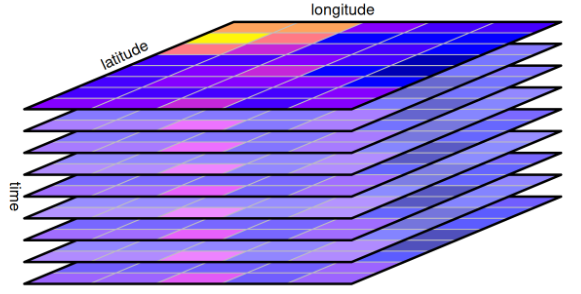

In [61]:
#type: ignore
import xarray as xr
import xee
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap

collection = ee.ImageCollection([image.select(["NDVI", "NDWI", "NBR"])])

ds = xr.open_dataset(
    collection,
    engine="ee",
    projection=ee.Projection("EPSG:4326").atScale(10),
    geometry=polygon_avila,
)

ds

<xarray.Dataset> Size: 5MB
Dimensions:  (time: 1, lon: 554, lat: 803)
Coordinates:
  * time     (time) int32 4B 0
  * lon      (lon) float64 4kB -4.722 -4.722 -4.722 ... -4.673 -4.673 -4.673
  * lat      (lat) float64 6kB 40.66 40.66 40.66 40.66 ... 40.73 40.73 40.73
Data variables:
    NDVI     (time, lon, lat) float32 2MB ...
    NDWI     (time, lon, lat) float32 2MB ...
    NBR      (time, lon, lat) float32 2MB ...
Attributes:
    crs:      EPSG:4326

In [62]:
# print(ds)
# print(ds.NDVI)
print(ds.NDVI.dims)
print(ds.NDVI.shape)
print(ds.NDVI.dtype)

('time', 'lon', 'lat')
(1, 554, 803)
float32


In [63]:
cmap_ndvi = LinearSegmentedColormap.from_list("NDVI", palette_ndvi)
cmap_ndwi = LinearSegmentedColormap.from_list("NDWI", palette_ndwi)
cmap_nbr = LinearSegmentedColormap.from_list("NBR", palette_nbr)

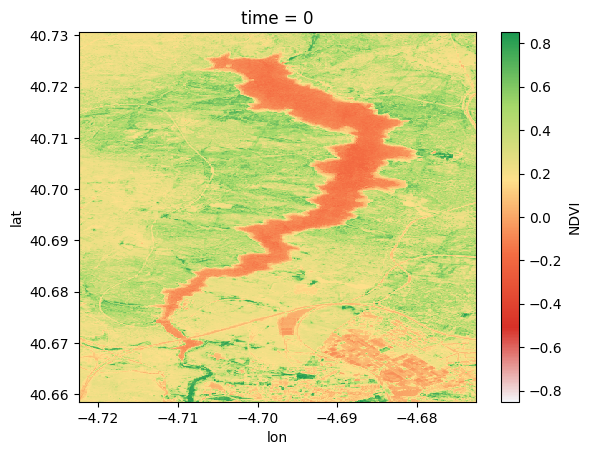

In [64]:
ds_ndvi = ds.NDVI.isel(time=0)
ds_ndvi.plot(
    x="lon",
    y="lat",
    cmap=cmap_ndvi,
)

In [65]:
# Seleccionar índices espectrales
indices = {
    "NDVI": {
        "data": ds["NDVI"].isel(time=0),
        "title": "NDVI — Vegetación",
        "cmap": cmap_ndvi,
        "vmin": -1,
        "vmax": 0.9,
    },
    "NDWI": {
        "data": ds["NDWI"].isel(time=0),
        "title": "NDWI — Agua",
        "cmap": cmap_ndwi,
        "vmin": -1,
        "vmax": 1,
    },
    "NBR": {
        "data": ds["NBR"].isel(time=0),
        "title": "NBR — Severidad quemado",
        "cmap": cmap_nbr,
        "vmin": -1,
        "vmax": 1,
    },
}

In [66]:
def style_axis(ax, facecolor="#111111"):
    ax.set_facecolor(facecolor)

    ax.tick_params(colors="white", labelsize=8)

    for spine in ax.spines.values():
        spine.set_color("#444444")

    ax.xaxis.label.set_color("white")
    ax.yaxis.label.set_color("white")
    ax.title.set_color("white")

def style_colorbar(cbar, label):
    cbar.set_label(label, color="white")
    cbar.ax.yaxis.set_tick_params(color="white")
    plt.setp(cbar.ax.get_yticklabels(), color="white")

def plot_index(ax, data, title, cmap, vmin, vmax, label):
    im = data.plot(
        ax=ax,
        x="lon",
        y="lat",
        cmap=cmap,
        vmin=vmin,
        vmax=vmax,
        add_colorbar=False
    )

    cbar = plt.colorbar(im, ax=ax, shrink=0.75)
    style_colorbar(cbar, label)

    ax.set_title(title)
    ax.set_xlabel("Longitud")
    ax.set_ylabel("Latitud")

    style_axis(ax)

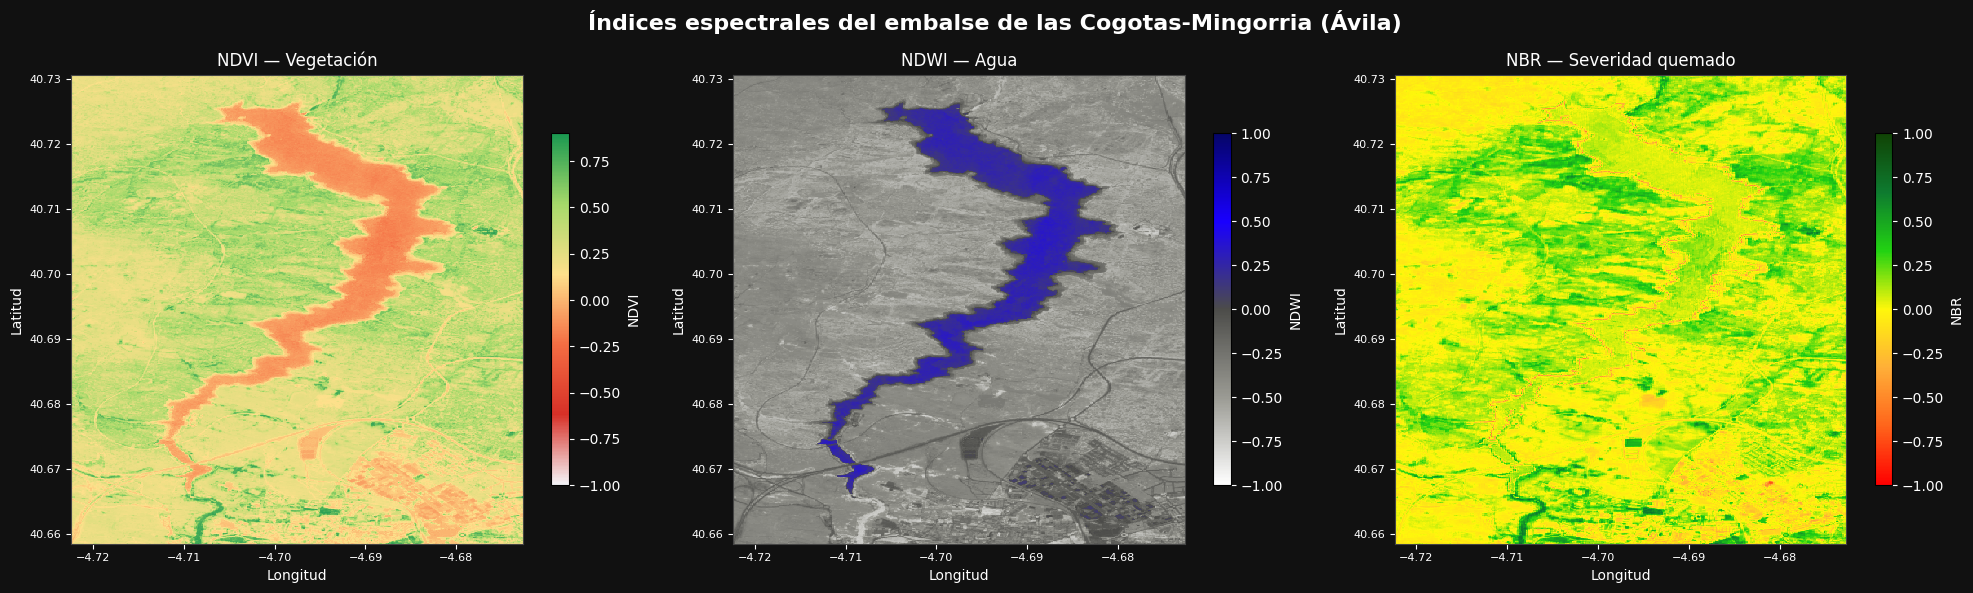

In [67]:
fig, axes = plt.subplots(1, len(indices), figsize=(20, 6), facecolor="#111111")

for ax, (label, config) in zip(axes, indices.items()):
    plot_index(
        ax=ax,
        data=config["data"],
        title=config["title"],
        cmap=config["cmap"],
        vmin=config["vmin"],
        vmax=config["vmax"],
        label=label
    )

fig.suptitle(
    "Índices espectrales del embalse de las Cogotas-Mingorria (Ávila)",
    fontsize=16,
    fontweight="bold",
    color="white"
)

plt.tight_layout()
plt.show()

### **Práctica: Análisis de índices espectrales**

#### Descripción

Calcula y analiza índices espectrales a partir de imágenes satelitales para evaluar las características de un área de estudio. Puedes utilizar el área trabajada en clase o elegir otra zona de interés, por ejemplo una zona agrícola, forestal, urbana, con cuerpos de agua o afectada por incendios.

El análisis debe incluir el cálculo de los índices `NDVI`, `NDWI` y `NBR`, su visualización en Notebook y la exportación de los resultados en formatos adecuados para análisis geoespacial.

#### Actividades

1. Seleccionar un área de estudio de interés y definir su geometría.
2. Definir un rango de fechas para obtener imágenes satelitales desde Google Earth Engine.
3. Calcular los índices espectrales `NDVI`, `NDWI` y `NBR`.
4. Organizar los resultados en una estructura tipo data cube utilizando `xarray`.
5. Revisar las dimensiones del dataset generado, identificando las dimensiones de tiempo, latitud y longitud.
6. Visualizar los índices espectrales en Notebook utilizando `matplotlib` u otras librerías de visualización.
7. Exportar los resultados en formato `Zarr`.
8. Exportar cada índice espectral como `Cloud Optimized GeoTIFF` (`COG`).

#### Entregable

Carpeta de datos `outputs/` y Notebook `.ipynb` con el cálculo de los índices espectrales, las visualizaciones ejecutadas, la exportación de resultados y un párrafo de análisis al final:

- Explicar qué zonas presentan mayor vigor vegetal según el `NDVI`.
- Identificar zonas con mayor humedad o presencia de agua según el `NDWI`.
- Analizar las zonas con mayor o menor respuesta según el `NBR`.
- Explicar qué ventajas tienen los formatos `Zarr` y `COG` para el análisis geoespacial.

La carpeta de datos debe incluir:

- `indices_espectrales.zarr/`
- `ndvi_cog.tif`
- `ndwi_cog.tif`
- `nbr_cog.tif`

#### *Extra*

Desarrollar una API utilizando `FastAPI` (integrada en el proyecto) que permita calcular índices espectrales a partir de Google Earth Engine.

La API debe implementar un endpoint `POST` capaz de:

- Recibir el área de estudio como una lista de coordenadas que represente un polígono.
- Recibir los parámetros de entrada, por ejemplo **rango de fechas** y **porcentaje máximo de nubosidad**.
- Construir la geometría del área de estudio a partir de las coordenadas recibidas.
- Calcular los índices espectrales `NDVI`, `NDWI` y `NBR` utilizando la collección `COPERNICUS/S2_SR_HARMONIZED`.
- Devolver una respuesta con las URLs tipo `XYZ raster tiles` para visualizar los resultados.

Ejemplo de entrada:

```json
{
  "area": [
    [-4.722404, 40.658504],
    [-4.722404, 40.730608],
    [-4.672623, 40.730608],
    [-4.672623, 40.658504],
    [-4.722404, 40.658504]
  ],
  "start_date": "2024-06-01",
  "end_date": "2024-06-30",
  "cloud_percentage": 20
}

Ejemplo de respuesta:

```json
{
  "ndvi": {
    "tile_url": "https://..."
  },
  "ndwi": {
    "tile_url": "https://..."
  },
  "nbr": {
    "tile_url": "https://..."
  }
}